In [1]:
import pandas as pd 


In [4]:
df = pd.read_csv(r"C:\Users\veda\Downloads\archive\Sample - Superstore.csv",encoding = 'ISO-8859-1')

In [6]:
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820


In [8]:
df.shape

(9994, 21)

In [9]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [17]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

df.columns()

In [19]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [20]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [21]:
df['Order Date']

0      2016-11-08
1      2016-11-08
2      2016-06-12
3      2015-10-11
4      2015-10-11
          ...    
9989   2014-01-21
9990   2017-02-26
9991   2017-02-26
9992   2017-02-26
9993   2017-05-04
Name: Order Date, Length: 9994, dtype: datetime64[ns]

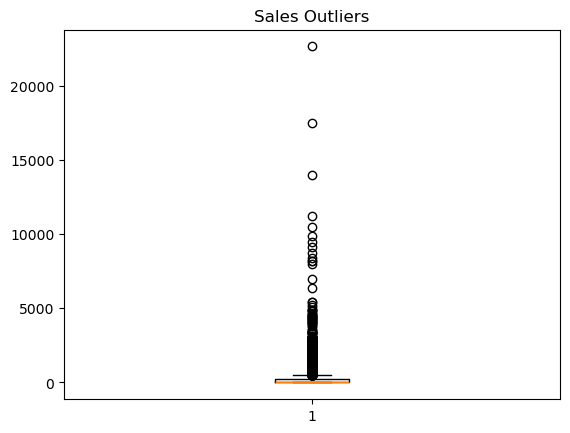

In [22]:
import matplotlib.pyplot as plt
plt.boxplot(df['Sales'])
plt.title('Sales Outliers')
plt.show()

In [23]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Sales'] < lower) | (df['Sales'] > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 1167


In [24]:
df[['Sales','Profit','Quantity','Discount']].describe()

,Sales,Profit,Quantity,Discount
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,3.789574,0.156203
std,623.245101,234.260108,2.225110,0.206452
min,0.444000,-6599.978000,1.000000,0.000000
25%,17.280000,1.728750,2.000000,0.000000
50%,54.490000,8.666500,3.000000,0.200000
75%,209.940000,29.364000,5.000000,0.200000
max,22638.480000,8399.976000,14.000000,0.800000


In [25]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

In [26]:
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

C:\Users\veda\AppData\Local\Temp\ipykernel_3876\601736891.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.groupby(pd.Grouper(key='Order Date',freq='M'))['Sales'].sum()


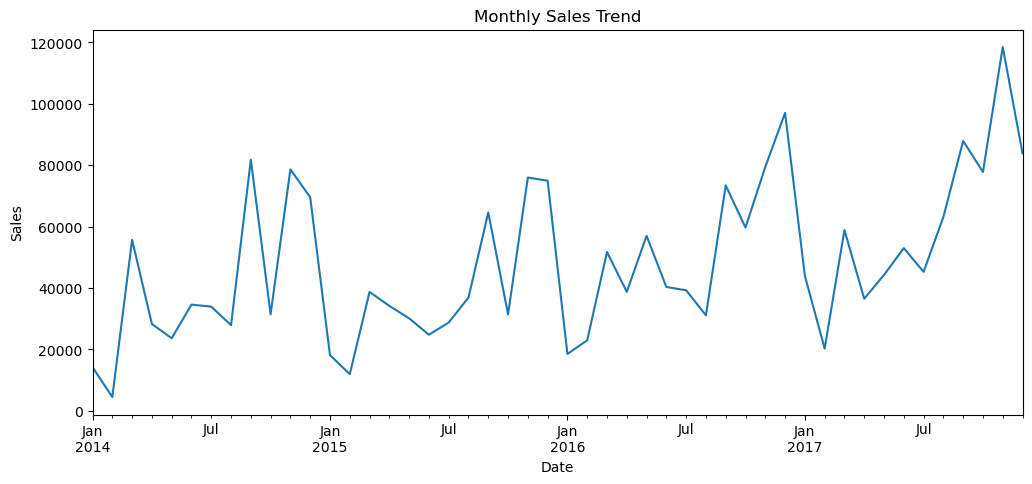

In [27]:
monthly_sales = df.groupby(pd.Grouper(key='Order Date',freq='M'))['Sales'].sum()

monthly_sales.plot(figsize=(12,5))
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

In [31]:
correlation = df[['Sales','Profit','Quantity','Discount']].corr()

print(correlation)

             Sales    Profit  Quantity  Discount
Sales     1.000000  0.479064  0.200795 -0.028190
Profit    0.479064  1.000000  0.066253 -0.219487
Quantity  0.200795  0.066253  1.000000  0.008623
Discount -0.028190 -0.219487  0.008623  1.000000


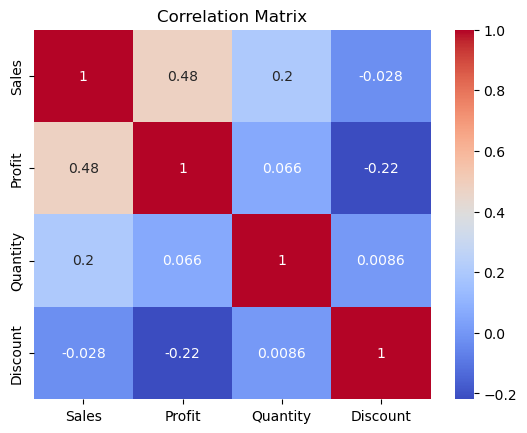

In [98]:
import seaborn as sns
sns.heatmap(correlation,annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

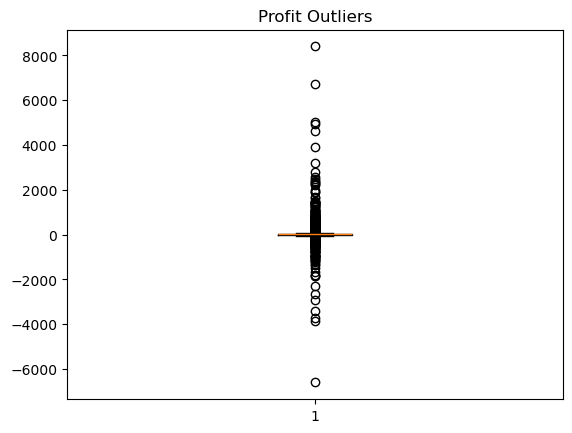

In [34]:
plt.boxplot(df['Profit'])
plt.title('Profit Outliers')
plt.show()

In [35]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter
df['Day'] = df['Order Date'].dt.day
df['DayOfWeek'] = df['Order Date'].dt.dayofweek

In [36]:
df[['Order Date','Year','Month','Quarter','DayOfWeek']].head()

,Order Date,Year,Month,Quarter,DayOfWeek
0,2016-11-08,2016,11,4,1
1,2016-11-08,2016,11,4,1
2,2016-06-12,2016,6,2,6
3,2015-10-11,2015,10,4,6
4,2015-10-11,2015,10,4,6


In [38]:
monthly_sales = df.groupby(
    pd.Grouper(key='Order Date',freq='ME')
)['Sales'].sum().reset_index()

In [39]:
monthly_sales['Lag_1'] = monthly_sales['Sales'].shift(1)

In [40]:
monthly_sales['Lag_2'] = monthly_sales['Sales'].shift(2)

In [41]:
monthly_sales['Rolling_Mean_3'] = (
    monthly_sales['Sales']
    .rolling(window=3)
    .mean()
)

In [42]:
df[['Category','Region']].head()

,Category,Region
0,Furniture,South
1,Furniture,South
2,Office Supplies,West
3,Furniture,South
4,Office Supplies,South


In [43]:
df = pd.get_dummies(
    df,
    columns=['Category','Region'],
    drop_first=True
)

In [44]:
corr = df.corr(numeric_only=True)
corr['Sales'].sort_values(
    ascending=False
)

Sales                       1.000000
Profit                      0.479064
Quantity                    0.200795
Category_Technology         0.170260
Region_East                 0.008588
Region_South                0.008431
Day                         0.003150
Month                      -0.000625
Row ID                     -0.001359
Quarter                    -0.002501
Region_West                -0.003708
DayOfWeek                  -0.009343
Year                       -0.009679
Postal Code                -0.023854
Discount                   -0.028190
Category_Office Supplies   -0.218568
Name: Sales, dtype: float64

In [47]:
print(df.columns)

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Segment', 'Country', 'City', 'State', 'Postal Code', 'Product ID',
       'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year',
       'Month', 'Quarter', 'Day', 'DayOfWeek', 'Category_Office Supplies',
       'Category_Technology', 'Region_East', 'Region_South', 'Region_West'],
      dtype='object')


In [48]:
print(df.shape)

(9994, 26)


In [49]:
from sklearn.linear_model import LinearRegression

In [50]:
from sklearn.ensemble import RandomForestRegressor

In [52]:
from statsmodels.tsa.arima.model import ARIMA

In [55]:
y = df['Sales']

In [56]:
X = df[['Quantity',
        'Discount',
        'Profit',
        'Year',
        'Month',
        'Quarter',
        'DayOfWeek']]

In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [58]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [59]:
y_pred = lr.predict(X_test)

In [62]:
from sklearn.metrics import mean_squared_error,r2_score

rmse = np.sqrt(
    mean_squared_error(y_test,y_pred)
)

r2 = r2_score(y_test,y_pred)

print("RMSE:",rmse)
print("R2 Score:",r2)

RMSE: 824.9072211331542
R2 Score: -0.15197712528537388


In [61]:
import numpy as np

In [63]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [64]:
rf_pred = rf.predict(X_test)

In [67]:
rmse_rf = np.sqrt(
    mean_squared_error(y_test,rf_pred)
)
r2_rf = r2_score(y_test,rf_pred)

print("RF RMSE:",rmse_rf)
print("RF R2:",r2_rf)

RF RMSE: 520.8077266143503
RF R2: 0.5408141653480997


In [68]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df = df.sort_values('Order Date')

In [69]:
X = df[['Quantity', 'Discount', 'Profit']]
y = df['Sales']

In [70]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [71]:
print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))

Training Records: 7995
Testing Records: 1999


In [72]:
print("Training Period:")
print(df['Order Date'][:split_index].min())
print(df['Order Date'][:split_index].max())

print("Testing Period:")
print(df['Order Date'][split_index:].min())
print(df['Order Date'][split_index:].max())

Training Period:
2014-01-03 00:00:00
2017-07-18 00:00:00
Testing Period:
2017-07-18 00:00:00
2017-12-30 00:00:00


In [73]:
train_last_date = df['Order Date'][:split_index].max()
test_first_date = df['Order Date'][split_index:].min()

print(train_last_date)
print(test_first_date)

2017-07-18 00:00:00
2017-07-18 00:00:00


In [74]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [75]:
y_pred = model.predict(X_test)

In [76]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 223.94836536527032
R² Score: 0.8537591315606641


In [77]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [78]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [79]:
y_pred = model.predict(X_test)

In [80]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [81]:
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("RMSE:", rmse)

RMSE: 529.5877400741796


In [82]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.18219679334695338


In [83]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(
    y_test,
    y_pred
)

print("MAPE:", mape)

MAPE: 7.498112939172911


In [84]:
results = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': y_pred
})

print(results.head())

      Actual Sales  Predicted Sales
3915       161.568       132.135061
3914       801.600      -283.971605
7043       198.744       214.404167
7044         9.184       119.979242
3916        16.096       125.525012


In [85]:
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

import numpy as np

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

mape = mean_absolute_percentage_error(
    y_test,
    y_pred
)

print("RMSE:", rmse)
print("R² Score:", r2)
print("MAPE:", mape)

RMSE: 529.5877400741796
R² Score: 0.18219679334695338
MAPE: 7.498112939172911


In [86]:
X = df[['Quantity', 'Discount', 'Profit']]
y = df['Sales']

In [87]:
df = df.sort_values('Order Date')

In [88]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [89]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

import numpy as np

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)
print("MAPE:", mape)

RMSE: 529.5877400741796
R² Score: 0.18219679334695338
MAPE: 7.498112939172911


In [91]:
monthly_sales = df.groupby(
    pd.Grouper(key='Order Date',freq='ME')
)['Sales'].sum()



In [96]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(results.head())

       Actual   Predicted
3915  161.568  132.135061
3914  801.600 -283.971605
7043  198.744  214.404167
7044    9.184  119.979242
3916   16.096  125.525012


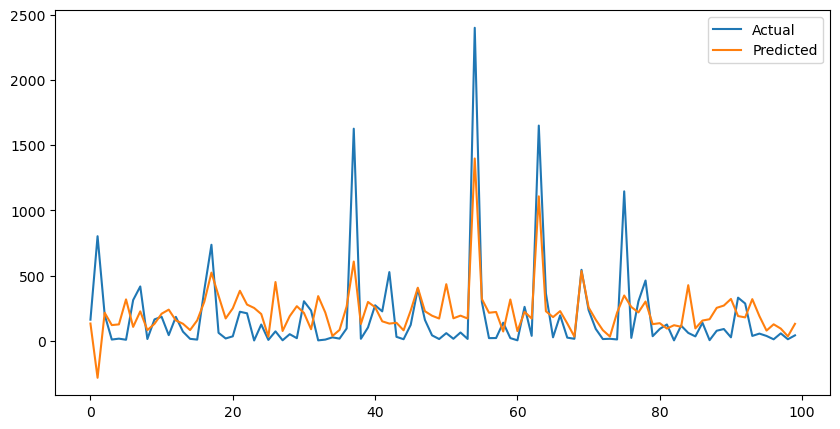

In [99]:
plt.figure(figsize=(10,5))
plt.plot(
    y_test.values[:100],
    label='Actual'
)
plt.plot(
    y_pred[:100],
    label='Predicted'
)
plt.legend()
plt.show()